import pandas as pd
import numpy as np
import scipy.stats as stats

# Load dataset
df = pd.read_csv('health_records_dataset.csv')
alpha = 0.05

# -------------------------------------------------------------
# 2. Confidence Intervals (95%)
# -------------------------------------------------------------
print("=== 2. 95% CONFIDENCE INTERVALS ===")
num_cols = ['age', 'weight', 'bmi', 'blood_pressure', 'cholesterol_level', 'glucose_level']
for col in num_cols:
    data = df[col]
    mean = data.mean()
    sem = stats.sem(data)
    ci = stats.t.interval(0.95, df=len(data)-1, loc=mean, scale=sem)
    print(f"{col:<20}: Mean = {mean:.2f} | 95% CI = [{ci[0]:.2f}, {ci[1]:.2f}]")

# -------------------------------------------------------------
# 4. Two-Sample Test (BMI: Diabetic vs. Non-Diabetic)
# -------------------------------------------------------------
print("\n=== 4. TWO-SAMPLE MEAN COMPARISON (t-test / z-test) ===")
group_diab = df[df['diabetes'] == True]['bmi']
group_nodiab = df[df['diabetes'] == False]['bmi']

t_stat, p_val_t = stats.ttest_ind(group_diab, group_nodiab)
crit_t = stats.t.ppf(1 - alpha/2, df=len(df)-2)

print(f"t-statistic: {t_stat:.4f} | Critical t: ±{crit_t:.4f} | p-value: {p_val_t:.4e}")
print("Decision:", "Reject H0" if p_val_t < alpha else "Fail to Reject H0")

# -------------------------------------------------------------
# 5. Chi-Square Test (Smoking Status vs. Hypertension)
# -------------------------------------------------------------
print("\n=== 5. CHI-SQUARE TEST OF INDEPENDENCE ===")
contingency = pd.crosstab(df['smoking_status'], df['hypertension'])
chi2_stat, p_val_chi2, dof, _ = stats.chi2_contingency(contingency)
crit_chi2 = stats.chi2.ppf(1 - alpha, df=dof)

print(contingency)
print(f"Chi2: {chi2_stat:.4f} | Critical Chi2: {crit_chi2:.4f} | p-value: {p_val_chi2:.4e}")
print("Decision:", "Reject H0 (Dependent)" if p_val_chi2 < alpha else "Fail to Reject H0 (Independent)")

# -------------------------------------------------------------
# 6. One-Way ANOVA (Blood Pressure across Age Groups)
# -------------------------------------------------------------
print("\n=== 6. ONE-WAY ANOVA ===")
age_groups = [group['blood_pressure'].values for _, group in df.groupby('age_group')]
f_stat, p_val_f = stats.f_oneway(*age_groups)
crit_f = stats.f.ppf(1 - alpha, dfn=len(age_groups)-1, dfd=len(df)-len(age_groups))

print(f"F-statistic: {f_stat:.4f} | Critical F: {crit_f:.4f} | p-value: {p_val_f:.4e}")
print("Decision:", "Reject H0 (Group Means Differ)" if p_val_f < alpha else "Fail to Reject H0")

# -------------------------------------------------------------
# 7. Covariance and Correlation
# -------------------------------------------------------------
print("\n=== 7. COVARIANCE & CORRELATION ===")
print("Covariance (Age vs BMI):", round(df['age'].cov(df['bmi']), 3))
print("Correlation (Age vs BMI):", round(df['age'].corr(df['bmi']), 3))
print("Covariance (BP vs BMI):", round(df['blood_pressure'].cov(df['bmi']), 3))
print("Correlation (BP vs BMI):", round(df['blood_pressure'].corr(df['bmi']), 3))

1.	Formulate at least two hypotheses from the dataset. Example:
○	H₀: Smoking has no effect on Diabetes prevalence.
○	H₁: Smoking affects Diabetes prevalence.

H₀: Smoking habit has no effect on hypertension prevalence (Smoking status and Hypertension are independent).
H₁: Smoking habit affects hypertension prevalence (Smoking status and Hypertension are dependent).


In [1]:
import pandas as pd
df=pd.read_csv('C:/Users/Lenovo/Desktop/Maths/PR2/health_records_dataset.csv')
df

,record_id,age_group,age,weight,gender,region,smoking_status,exercise_frequency,bmi,blood_pressure,diabetes,hypertension,cholesterol_level,glucose_level,visit_date
0,71ff0672-043c-4dbc-82a6-1b8dab19e1e9,46-60,56,70,Other,East,Non-Smoker,Weekly,27.4,114.7,False,False,210.4,103.4,2024-05-06
1,b7cd1647-6cef-45d1-97d4-c48530d43201,60+,69,97,Male,East,Non-Smoker,Weekly,34.0,136.7,True,True,208.5,147.1,2024-07-11
2,8a3e0fed-ceb7-4c8a-9ff0-ac9f18a048b5,46-60,46,52,Female,North,Non-Smoker,Weekly,17.8,132.1,False,False,209.8,113.9,2025-09-18
3,7c45095b-f97d-4d63-81d0-4efb3ed2a4bc,26-35,32,106,Female,South,Non-Smoker,Weekly,39.3,132.2,True,True,194.5,132.0,2026-02-12
4,b7c5f73e-ff9a-4f23-91c7-e0ffda9104ce,46-60,60,62,Female,South,Non-Smoker,Weekly,24.4,131.3,False,True,255.0,113.2,2025-06-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,48206456-d884-453d-9368-b64aad7f1b48,60+,63,72,Female,West,Non-Smoker,Daily,26.6,118.9,False,False,200.4,102.3,2024-08-02
496,9a3accda-9c45-490f-a797-a1ca75df496d,36-45,41,79,Female,East,Non-Smoker,Weekly,31.4,116.8,True,False,225.8,166.6,2025-04-04
497,986779ed-c218-4b1b-b9a9-249f00bf1c6b,60+,67,107,Female,North,Former Smoker,Never,40.9,140.7,True,True,223.8,222.7,2025-04-02
498,effda577-d751-4a92-905e-97d599839218,46-60,49,69,Female,South,Former Smoker,Daily,26.2,129.0,False,False,191.2,113.4,2026-03-12


2.	Calculate Confidence Intervals for key numerical data like age, weight, etc.

In [ ]:

from scipy.stats import t
import numpy as np


columns = [ What about What, you're a potato, You know, 'cause You can.
    "age",
    "weight"
]

confidence = 0.95

for column in columns:

    data = df[column]

    n = len(data)
    mean = data.mean()
    std = data.std()

    t_critical = t.ppf(0.975, df=n-1)

    margin_error = t_critical * (std / np.sqrt(n))

    lower = mean - margin_error
    upper = mean + margin_error

    print(f"\n{column}")
    print(f"Mean = {mean:.2f}")
    print(f"95% CI = ({lower:.2f}, {upper:.2f})")



age
Mean = 49.91
95% CI = (48.31, 51.51)

weight
Mean = 78.21
95% CI = (76.78, 79.63)


3.	Find the Critical Value and p-value to interpret the test results.

Significance level: 0.05 
t-statistic:4.9642
Critical value:= +-1.9647
p-value:9.49*10^-7

Significance level (alpha) = 0.05

Since p-value (0.00000095) < 0.05:
    Reject H0

4.	Perform z-test or t-test based on sample size (mean comparison across groups).

In [9]:
diabetes_yes=df[df['diabetes']==True]['bmi']
diabetes_no=df[df['diabetes']==False]['bmi']

mean_yes=diabetes_yes.mean()
mean_no=diabetes_no.mean()
print('mean_diabetes_yes',mean_yes)
print('mean_diabetes_no',mean_no)

#performing t_test (independent)
from scipy.stats import ttest_ind
t_statistics,p_value=(ttest_ind(diabetes_yes,diabetes_no))
print('t_statistics',t_statistics)
print('p_value',p_value)



significance_level=0.05
if p_value<significance_level:
  print('''there is a significance difference in mean of bmi
  of diabetes and non diabets people''')
else:
  print('''there is no significance difference in mean of bmi
  of diabetic and non diabetic people''')

mean_diabetes_yes 28.722772277227723
mean_diabetes_no 26.641610738255032
t_statistics 4.964195194680015
p_value 9.490238069330863e-07
there is a significance difference in mean of bmi
  of diabetes and non diabets people


5.	Conduct a chi-square test on categorical data (e.g., Smoking habit vs Disease).

In [12]:
table=pd.crosstab(df['smoking_status'],df['diabetes'])
table
from scipy.stats import chi2_contingency

chi2_stat, p_value, df_value, expected=chi2_contingency(table)
print('expected',expected)
print('p_value',p_value)
print('chi2_stat',chi2_stat)
print('df_value',df_value)

expected [[ 73.308  49.692]
 [167.476 113.524]
 [ 57.216  38.784]]
p_value 0.41887194858311494
chi2_stat 1.7403800354846568
df_value 2


In [14]:
import pandas as pd
from scipy.stats import chi2, chi2_contingency

# 1. Compute chi2_stat from the contingency table
ct = pd.crosstab(df['smoking_status'], df['diabetes'])
chi2_stat, p_val, d_f, _ = chi2_contingency(ct)

# 2. Critical value calculation (pass d_f, not df)
alpha = 0.05
critical_val = chi2.ppf(1 - alpha, df=d_f)

# 3. Decision rule (right-tailed test)
if chi2_stat > critical_val:
  print('reject null hypothesis (smoking and diabetes are dependent)')
else:
  print(
      'failed to reject the null hypothesis (smoking and diabetes are'
      ' independent)'
  )

failed to reject the null hypothesis (smoking and diabetes are independent)


6.	Perform an ANOVA test to check if age groups significantly differ in disease rate.

In [15]:
df['diabetes_numeric']=df['diabetes'].map({True:1,False:0})
df['diabetes_numeric']
group1 = df[df["age_group"] == "18-25"]["diabetes_numeric"]
group2 = df[df["age_group"] == "26-35"]["diabetes_numeric"]
group3 = df[df["age_group"] == "36-45"]["diabetes_numeric"]
group4 = df[df["age_group"] == "46-60"]["diabetes_numeric"]
group5 = df[df["age_group"] == "60+"]["diabetes_numeric"]
from scipy.stats import f_oneway
f_stat, p_value = f_oneway(group1,group2,group3,group4,group5)
f_stat
p_value
if p_value < 0.05:
    print("Reject null hypothesis")
    print("disease rates are significantly different among age groups")
else:
    print("Fail to reject null hypothesis")
    print("there is not enough evidence that disease rates differ among age groups")

Reject null hypothesis
disease rates are significantly different among age groups


7.	Calculate Covariance and Correlation between continuous variables (e.g., Age vs. BMI).

covariance is positive means age and bmi tends to increase


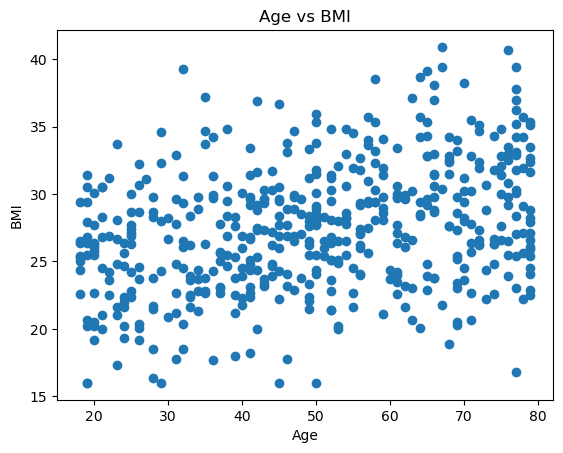

Pearson correlation: 0.3360481396999569
Spearman correlation: 0.3243485261345209
there is significantly low relationship betweeen age and bmi


In [16]:
df['age'].cov(df['bmi'])
print('covariance is positive means age and bmi tends to increase')
df['age'].corr(df['bmi'])
import matplotlib.pyplot as plt

plt.scatter(df["age"], df["bmi"])

plt.xlabel("Age")
plt.ylabel("BMI")
plt.title("Age vs BMI")

plt.show()
pearson = df["age"].corr(df["bmi"], method="pearson")
spearman = df["age"].corr(df["bmi"], method="spearman")

print("Pearson correlation:", pearson)
print("Spearman correlation:", spearman)
print('there is significantly low relationship betweeen age and bmi')